# Testing the `BedLevelEvolution` component

This notebook shows how to use the `BedLevelEvolution` Landlab component (in `BedLevelEvolution.py`, next to this notebook) together with the built-in `TidalFlowCalculator` component.

In [1]:
import sys
from pathlib import Path

# make sure BedLevelEvolution.py (in this same folder) is importable
sys.path.append(str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from landlab import RasterModelGrid, imshow_grid
from landlab.components import TidalFlowCalculator

from BedLevelEvolution import BedLevelEvolution

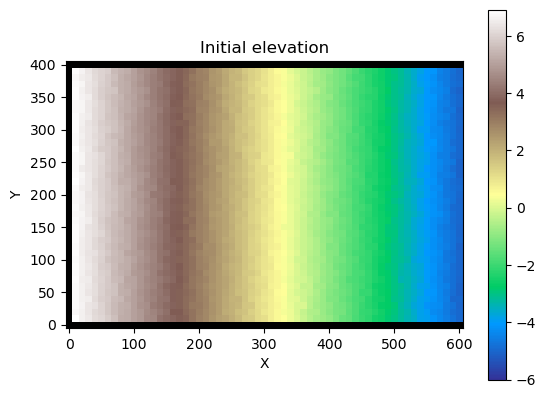

In [2]:
grid = RasterModelGrid((41, 61), xy_spacing=10.0)

x = grid.node_x
z = -5.0 + 0.02 * (x.max() - x) + np.random.default_rng(0).normal(0, 0.05, x.size)
grid.at_node["topographic__elevation"] = z

# open boundary on the east edge (ocean); closed on the other three sides
grid.set_closed_boundaries_at_grid_edges(False, True, True, True)

imshow_grid(grid, "topographic__elevation", cmap="terrain", vmin=-6)
plt.title("Initial elevation")
plt.show()

In [3]:
tfc = TidalFlowCalculator(grid, tidal_range=2.0, roughness=0.01)
tfc.run_one_step()

blc = BedLevelEvolution(
    grid,
    diffusivity=3.75,
    relative_sea_level_rise=0.0,
    settling_velocity=0.03,
    sediment_concentration=0.05,
    critical_shear_stress=0.2,
    erodibility_coefficient=1e-3,
    mannings_n=0.035,
)

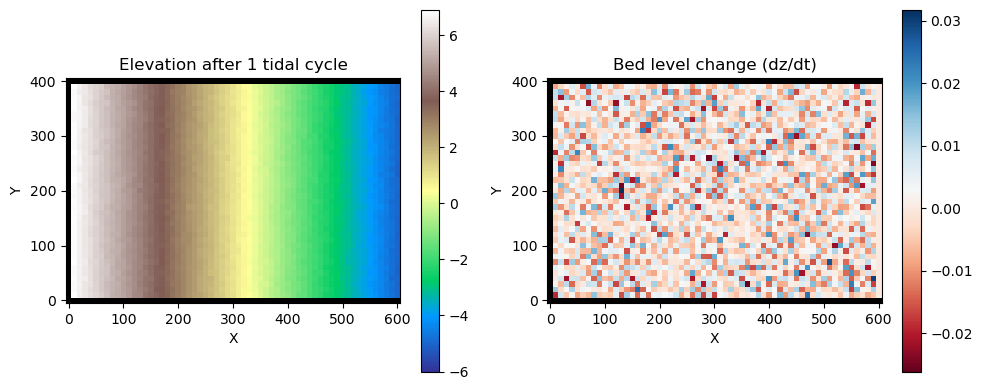

In [4]:
dz_dt = blc.run_one_step(dt=1.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.sca(axes[0])
imshow_grid(grid, "topographic__elevation", cmap="terrain", vmin=-6)
axes[0].set_title("Elevation after 1 tidal cycle")

plt.sca(axes[1])
imshow_grid(grid, dz_dt, cmap="RdBu")
axes[1].set_title("Bed level change (dz/dt)")
plt.tight_layout()
plt.show()

tidal cycle number: 0


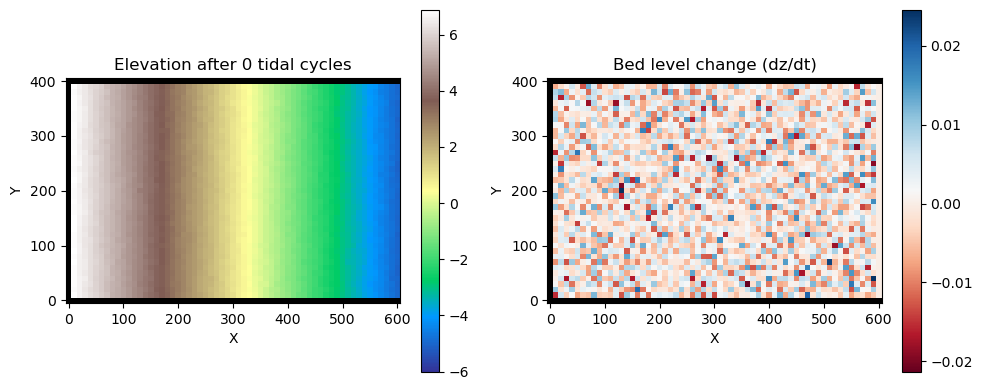

tidal cycle number: 50


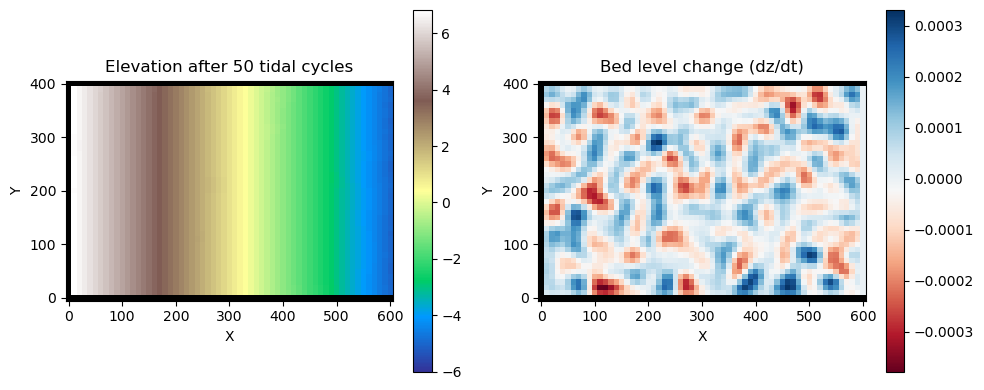

tidal cycle number: 100


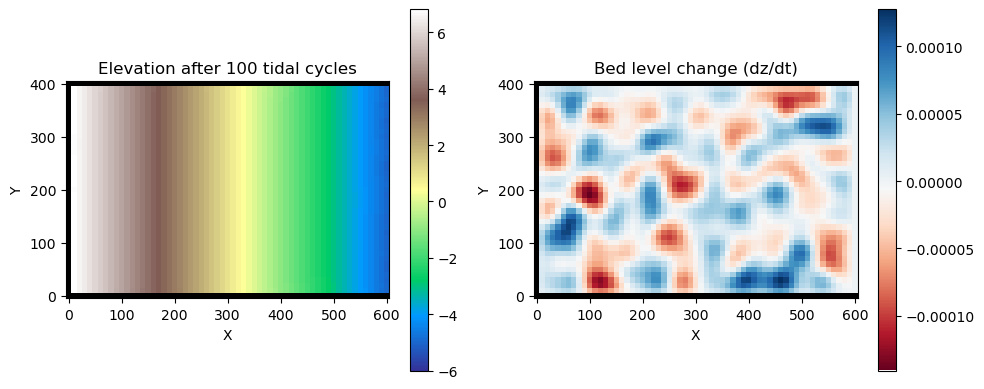

tidal cycle number: 150


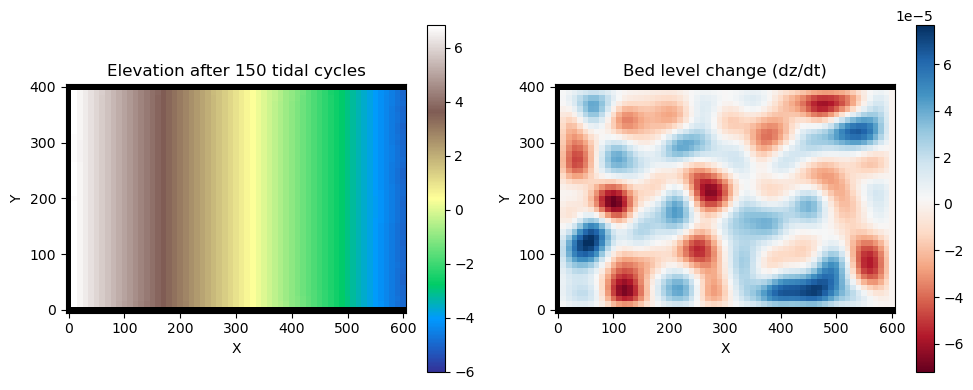

tidal cycle number: 200


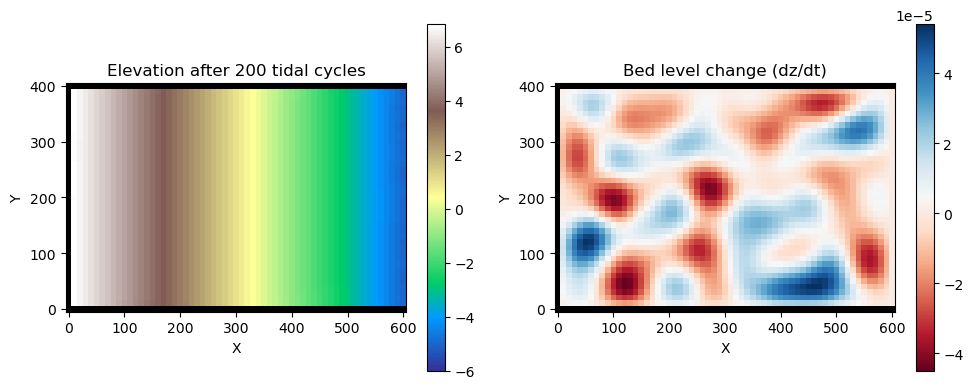

In [5]:
number_of_tidal_cycles = 200
plot_interval = 50

for i in range(number_of_tidal_cycles + 1):
    # recompute tidal flow velocities and mean water depth
    tfc.run_one_step()

    # advance the bed level by one tidal cycle
    dz_dt = blc.run_one_step(dt=1.0)

    if i % plot_interval == 0:
        print(f"tidal cycle number: {i}")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        plt.sca(axes[0])
        imshow_grid(grid, "topographic__elevation", cmap="terrain", vmin=-6)
        axes[0].set_title(f"Elevation after {i} tidal cycles")

        plt.sca(axes[1])
        imshow_grid(grid, dz_dt, cmap="RdBu")
        axes[1].set_title("Bed level change (dz/dt)")
        plt.tight_layout()
        plt.show()

I did some sensitivity tests and it suggests that this component is not well suited to spinning up channel networks from an idealized bathymetry:

- `diffusivity * grad^2(z)` damps perturbations fast -- while a perturbation is exactly what a channel would need to start growing. Even with `diffusivity` cut ~40x, `critical_shear_stress` cut 10x, `erodibility_coefficient` raised 10x, and persistent noise, the bed still relaxes toward a smooth equilibrium profile instead of channelizing.
- The erosion law's shear stress includes a `depth^(-1/3)` term, so a locally deeper spot doesn't automatically experience more shear unless flow velocity increases enough to outweigh it. There's no guaranteed positive feedback (deepen -> concentrate flow -> erode more -> deepen further) built into this formulation.

A more appropriate application is short-term bed-level-change prediction on top of an already-channelized, realistic bathymetry (e.g. a real DEM, as in the tidal-flow presentation notebook), where the existing channel network already concentrates flow enough to produce meaningful spatial differences in shear stress -- using the model to project incremental erosion/deposition/sea-level-rise response, rather than to generate channel morphology from scratch.